# Demonstration of distribution reweighting

**hep_ml.reweight** contains methods to reweight distributions. 
Typically we use reweighting of monte-carlo to fight drawbacks of simulation, though there are many applications.

In this example we reweight multidimensional distibutions: `original` and `target`, the aim is to find new weights for original distribution, such that these multidimensional distributions will coincide. 

Here we have a __toy example__ without a real physics meaning.

Pay attention: equality of distibutions for each feature $\neq$ equality of multivariate distributions.

All samples are divided into **training** and **validation** part. Training part is used to fit reweighting rule and test part is used to estimate reweighting quality.

In [237]:
%matplotlib inline

import numpy
import uproot

# import root_numpy
import uproot
import pandas
import pandas as pd
from hep_ml import reweight
from matplotlib import pyplot as plt

### Downloading data

In [238]:
# columns = ['hSPD', 'pt_b', 'pt_phi', 'vchi2_b', 'mu_pt_sum']

# original = root_numpy.root2array('../data/MC_distribution.root', branches=columns)
# target = root_numpy.root2array('../data/RD_distribution.root', branches=columns)

# original = pandas.DataFrame(original)
# target = pandas.DataFrame(target)

# original_weights = numpy.ones(len(original))

In [239]:
# columns = ['hSPD', 'pt_b', 'pt_phi', 'vchi2_b', 'mu_pt_sum']

# # Load data from the ROOT file using uproot
# original_file = uproot.open('./data/MC_distribution.root')
# target_file = uproot.open('./data/RD_distribution.root')

# # Convert the branches into Pandas DataFrames
# original = original_file["tree"].arrays(columns, library="pd")
# target = target_file["tree"].arrays(columns, library="pd")

# # Create weights for the original dataset
# original_weights = numpy.ones(len(original))

# # Display results
# print(original.head())
# print(target.head())

In [266]:
columns = ['Pip_cosTheta','Pip_p']
# columns += ['Dp_CMS_cosTheta']
# columns +=  ['Pip_dr',
    # 'Dp_cosAngleBetweenMomentumAndVertexVectorInXYPlane',
    # 'etapip_Eta_Easym',
    # 'Dp_Psum',
    # 'etapip_Eta_daughterDiffOfPhi_0_1',
    # 'Dp_cosHelicityAngleMomentum']

In [267]:
columns_to_drop = ['Dp_isSignal','Dp_M','Pip_charge','Pip_genMotherPDG','Pip_pionID']

In [268]:
import glob

# base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/Kspip/MC15rd_etaetapip_loose_v3_241129"
base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/Kspip/MC15rd_Kspip_loose_v7_241220_Ks_nomassconst"

cm_elements = ["MCrd_Ks_e7_18_4S_v3", "MCrd_Ks_e20_b26_v1", "MCrd_Ks_e20_e26_4S_v2", "MCrd_Ks_e21_5S_scan_v1", "MCrd_Ks_mori_off_v1"]
cut_expression = "Dp_isSignal == 1"

file_list = []
for element in cm_elements:
    # pattern = f"{base_path}/{element}/etapip_pipipi/Ks/*.root"
    pattern = f"{base_path}/{element}/*.root"
    file_list += glob.glob(pattern)


dataframes = []
# Process each file
for file_name in file_list:
    # Load the ROOT file and tree
    file = uproot.open(file_name)
    tree = file["Ks"]

    # Specify the branches you want to extract
    # branches = ['Pip_pionID','Dp_Psum','Pip_genMotherID','etapip_Eta_genMotherID','Pip_genMotherPDG','etapip_Eta_genMotherPDG','Dp_cosHelicityAngleMomentum','Pip_dr',"Dp_isSignal","Dp_cosAngleBetweenMomentumAndVertexVectorInXYPlane", "Pip_p","Dp_CMS_p","etapip_Eta_p","CFT_prob","Dp_M","num_Dstar_no_nan",]  # Replace with actual branch names

    branches =  columns + columns_to_drop
    # Convert the selected branches to a Pandas DataFrame
    # df_temp = tree.arrays(branches, library="pd")
    df_temp = tree.arrays(
        branches,
        library="pd",
        entry_start=None,  # Optional: start at a specific entry
        entry_stop=None,   # Optional: stop at a specific entry
        filter_name=branches,  # Load only specified branches
        cut=cut_expression  # Apply the cut
    )
    # df_temp = tree.arrays(library="pd")

    # Append the DataFrame to the list
    dataframes.append(df_temp)

# Concatenate all DataFrames into a single DataFrame
original = pd.concat(dataframes, ignore_index=True)

# df_bkg = df_bkg.query('Dp_isSignal!=1')
# df_bkg = df_bkg.query('(Pip_genMotherID!=etapip_Eta_genMotherID) | abs(Pip_genMotherPDG)!=431 | abs(etapip_Eta_genMotherPDG)!=431')

In [269]:
original = original.query('Pip_p>0.4')
# original = original.query('Pip_pionID<0.01')

# df_bkg = df_bkg.query('Pip_p>0.9')
# df_bkg = df_bkg.query('Dp_M> 1.7 & Dp_M<2.1')
# df_bkg = df_bkg.query('Dp_M> 1.8 & Dp_M<2.05')

In [270]:
original = original.drop(columns=columns_to_drop)

In [271]:
original.describe()

,Pip_cosTheta,Pip_p
count,2.294973e+06,2.294973e+06
mean,2.873514e-01,1.840492e+00
std,4.892844e-01,9.769524e-01
min,-9.083980e-01,4.000025e-01
25%,-1.018812e-01,1.006664e+00
50%,3.684614e-01,1.744987e+00
75%,7.271024e-01,2.509786e+00
max,9.774101e-01,7.028467e+00


In [272]:
# Create weights for the original dataset
original_weights = numpy.ones(len(original))

In [273]:
base_path_sig = "/share/storage/jykim/storage_ghi/Ntuples_ghi_2/MC15rd_sigMC"
# elements_sig = ["DptoetaKp_gg", "DptoetaKp_gg_cc"]
# elements_sig = ["Dptoetapip_gg", "Dptoetapip_gg_cc"]
# elements_sig = ["Dsptoetapip_pipipi", "Dsptoetapip_pipipi_cc"]
elements_sig = ["Dptoetapip_pipipi", "Dptoetapip_pipipi_cc"]

# elements_sig = ["DsptoetaKp_gg", "DsptoetaKp_gg_cc"]

# project_name = "241129_loose_v3/etapip_gg"
project_name = "241213_loose_v7/etapip_pipipi"

file_list_sig = []
for element in elements_sig:
    pattern = f"{base_path_sig}/{element}/{project_name}/*BCS.root"
    file_list_sig += glob.glob(pattern)

In [274]:
dataframes_signal = []
# cut_expression = "Dp_isSignal == 1"  # Replace with your actual cut condition
cut_expression = "Dp_M>0"  # Replace with your actual cut condition

for file_name in file_list_sig:
    # Load the ROOT file and tree
    file = uproot.open(file_name)
    tree = file["etapip_pipipi"]

    # Specify the branches you want to extract
    #branches = ['Dp_Psum','dM_pi0_mask_nonan','dM_pi0_mask_2_nonan','Pip_genMotherID','etapip_Eta_genMotherID','Pip_genMotherPDG','etapip_Eta_genMotherPDG','Dp_cosHelicityAngleMomentum','Pip_dr',"Dp_isSignal","Dp_cosAngleBetweenMomentumAndVertexVectorInXYPlane", "Pip_p","Dp_CMS_p","etapip_Eta_Easym","etapip_Eta_p","CFT_prob","Dp_M","num_Dstar_no_nan","etapip_Eta_daughterDiffOfPhi_0_1","etapip_Eta_daughterAngle_0_1"]  # Replace with actual branch names
    # branches = ['Dp_Psum','dM_pi0_mask','dM_pi0_mask_2','Pip_genMotherID','etapip_Eta_genMotherID','Pip_genMotherPDG','etapip_Eta_genMotherPDG','Dp_cosHelicityAngleMomentum','Pip_dr',"Dp_isSignal","Dp_cosAngleBetweenMomentumAndVertexVectorInXYPlane", "Pip_p","Dp_CMS_p","etapip_Eta_Easym","etapip_Eta_p","CFT_prob","Dp_M","num_Dstar_no_nan","etapip_Eta_daughterDiffOfPhi_0_1","etapip_Eta_daughterAngle_0_1"]  # Replace with actual branch names
    # branches = ['Pip_pionID','Dp_Psum','dM_pi0_mask_nonan','dM_pi0_mask_2_nonan','Pip_genMotherID','etapip_Eta_genMotherID','Pip_genMotherPDG','etapip_Eta_genMotherPDG','Dp_cosHelicityAngleMomentum','Pip_dr',"Dp_isSignal","Dp_cosAngleBetweenMomentumAndVertexVectorInXYPlane", "Pip_p","Dp_CMS_p","etapip_Eta_Easym","etapip_Eta_p","CFT_prob","Dp_M","num_Dstar_no_nan","etapip_Eta_daughterDiffOfPhi_0_1","etapip_Eta_daughterAngle_0_1"]  # Replace with actual branch names
    branches = branches =  columns + columns_to_drop + ['etapip_Eta_genMotherID','etapip_Eta_genMotherPDG','Pip_genMotherID']
    # Convert the selected branches to a Pandas DataFrame
    # df_temp = tree.arrays(branches, library="pd")
    df_temp = tree.arrays(
        branches,
        library="pd",
        entry_start=None,  # Optional: start at a specific entry
        entry_stop=None,   # Optional: stop at a specific entry
        filter_name=branches,  # Load only specified branches
        cut=cut_expression  # Apply the cut
    )
    # df_temp = tree.arrays(library="pd")

    # Append the DataFrame to the list
    dataframes_signal.append(df_temp)


target = pd.concat(dataframes_signal, ignore_index=True)


In [275]:
# target = target.query('Pip_pionID<0.01')
# target = target.query('(Pip_genMotherID==etapip_Eta_genMotherID) & abs(Pip_genMotherPDG)==431 & abs(etapip_Eta_genMotherPDG)==431')
target = target.query('Dp_isSignal == 1')


In [276]:
target = target.drop(columns=columns_to_drop + ['etapip_Eta_genMotherID','etapip_Eta_genMotherPDG','Pip_genMotherID'])

In [277]:
target.describe()

,Pip_cosTheta,Pip_p
count,477152.000000,477152.000000
mean,0.314257,1.651737
std,0.475660,0.853905
min,-0.899318,0.400013
25%,-0.051525,0.949441
50%,0.402249,1.534602
75%,0.735116,2.211572
max,0.978242,5.688436


### prepare train and test samples

* train part is used to train reweighting rule
* test part is used to evaluate reweighting rule comparing the following things: 
    * Kolmogorov-Smirnov distances for 1d projections
    * n-dim distibutions using ML (see below).

In [278]:
from sklearn.model_selection import train_test_split
# divide original samples into training ant test parts
original_train, original_test = train_test_split(original)
# divide target samples into training ant test parts
target_train, target_test = train_test_split(target)

original_weights_train = numpy.ones(len(original_train))
original_weights_test = numpy.ones(len(original_test))

In [279]:
from hep_ml.metrics_utils import ks_2samp_weighted
hist_settings = {'bins': 100, 'density': True, 'alpha': 0.7}

def draw_distributions(original, target, new_original_weights):
    plt.figure(figsize=[15, 12])
    for id, column in enumerate(columns, 1):
        xlim = numpy.percentile(numpy.hstack([target[column]]), [0.01, 99.99])
        plt.subplot(3, 3, id)
        plt.hist(original[column], weights=new_original_weights, range=xlim, **hist_settings)
        plt.hist(target[column], range=xlim, **hist_settings)
        plt.title(column)
        print('KS over ', column, ' = ', ks_2samp_weighted(original[column], target[column], 
                                         weights1=new_original_weights, weights2=numpy.ones(len(target), dtype=float)))

### Notice:
Setting `density=True` in `hist_settings` above means that the histograms will be drawn normalized below, so that the area under each histogram integrates to 1. This can obscure the fact that the weights produced by `predict_weights` are not normalized; if you want the number of effective events to be the same after reweighting, you must renormalize the weights manually--see the `reweight` documentation.


## Original distributions
KS = Kolmogorov-Smirnov distance

In [280]:
# pay attention, actually we have very few data
len(original), len(target)

(2294973, 477152)

KS over  Pip_cosTheta  =  0.025449290790360013
KS over  Pip_p  =  0.09390596601779089


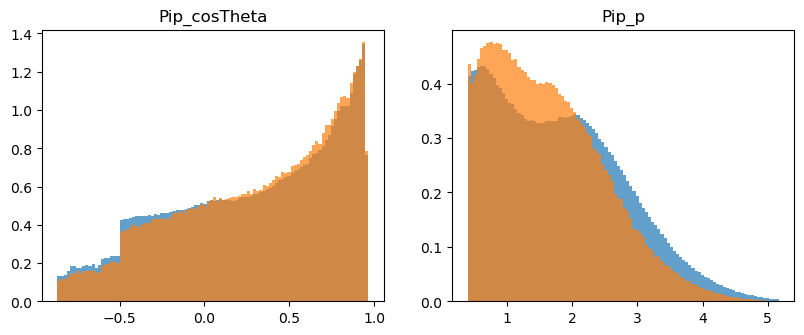

In [281]:
draw_distributions(original, target, original_weights)

### train part of original distribution

KS over  Pip_cosTheta  =  0.025421522902764004
KS over  Pip_p  =  0.0939294445840847


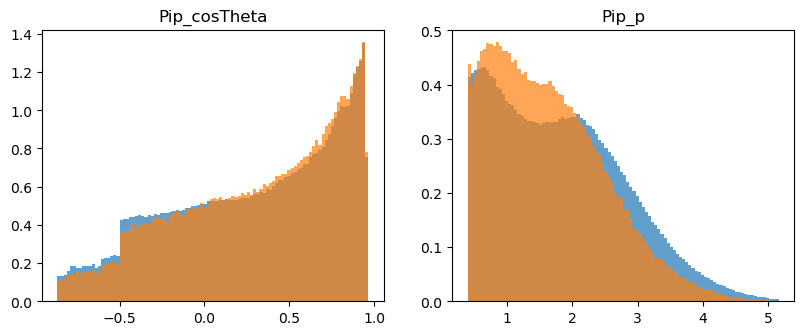

In [282]:
draw_distributions(original_train, target_train, original_weights_train)

### test part for target distribution

KS over  Pip_cosTheta  =  0.026261696411503388
KS over  Pip_p  =  0.09464518379058917


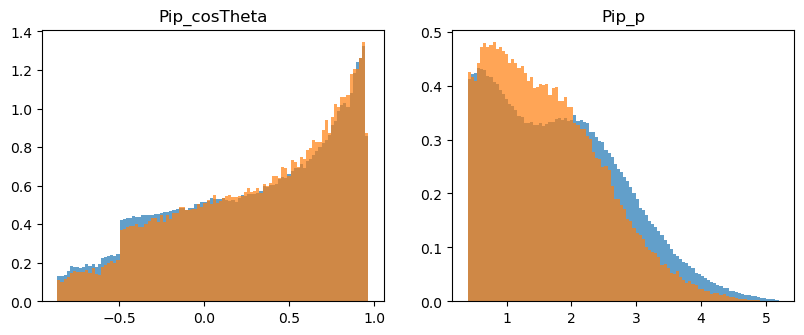

In [283]:
draw_distributions(original_test, target_test, original_weights_test)

# Bins-based reweighting in n dimensions
Typical way to reweight distributions is based on bins.

KS over  Pip_cosTheta  =  0.005009184119275256
KS over  Pip_p  =  0.006344133530314711


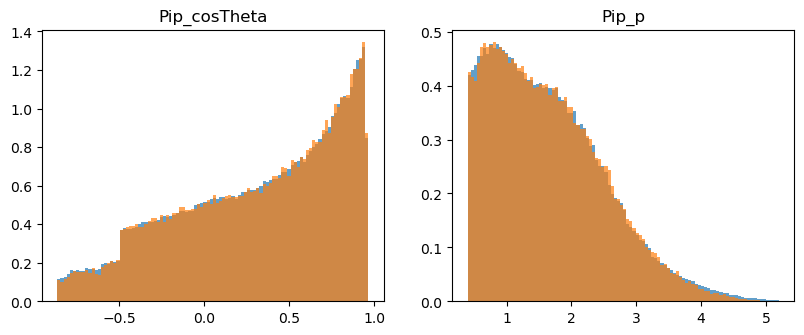

In [284]:
bins_reweighter = reweight.BinsReweighter(n_bins=20, n_neighs=1.)
# bins_reweighter = reweight.BinsReweighter(n_bins=10, n_neighs=1.)

bins_reweighter.fit(original_train, target_train)

bins_weights_test = bins_reweighter.predict_weights(original_test)
# validate reweighting rule on the test part comparing 1d projections
draw_distributions(original_test, target_test, bins_weights_test)

# Gradient Boosted Reweighter

This algorithm is inspired by gradient boosting and is able to fight curse of dimensionality.
It uses decision trees and special loss functiion (**ReweightLossFunction**).

**GBReweighter** supports negative weights (to reweight MC to splotted real data).

KS over  Pip_cosTheta  =  0.00459650117354915
KS over  Pip_p  =  0.003515289920750897


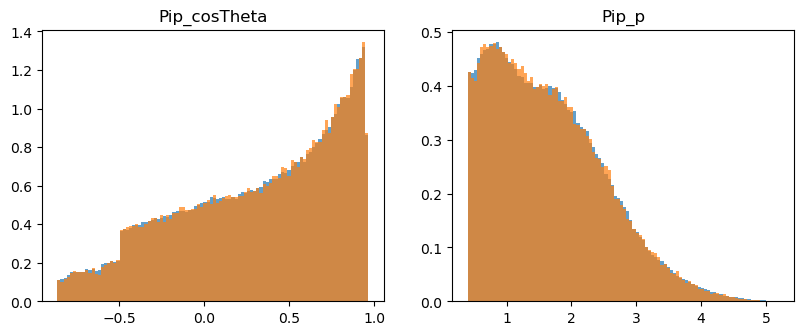

In [285]:
# reweighter = reweight.GBReweighter(n_estimators=50, learning_rate=0.1, max_depth=3, min_samples_leaf=1000, 
                                   # gb_args={'subsample': 0.4})
reweighter = reweight.GBReweighter(n_estimators=50, learning_rate=0.1, max_depth=3, min_samples_leaf=1000, 
                                   gb_args={'subsample': 0.4})
# reweighter = reweight.GBReweighter(n_estimators=100, learning_rate=0.1, max_depth=3, min_samples_leaf=500, 
                                   # gb_args={'subsample': 0.4})
reweighter.fit(original_train, target_train)

gb_weights_test = reweighter.predict_weights(original_test)
# validate reweighting rule on the test part comparing 1d projections
draw_distributions(original_test, target_test, gb_weights_test)

## Comparing some simple expressions:
the most interesting is checking some other variables in multidimensional distributions (those are expressed via original variables).

In [286]:
def check_ks_of_expression(expression):
    col_original = original_test.eval(expression, engine='python')
    col_target = target_test.eval(expression, engine='python')
    w_target = numpy.ones(len(col_target), dtype='float')
    print('No reweight   KS:', ks_2samp_weighted(col_original, col_target, 
                                                 weights1=original_weights_test, weights2=w_target))
    print('Bins reweight KS:', ks_2samp_weighted(col_original, col_target, 
                                                 weights1=bins_weights_test, weights2=w_target))
    print('GB Reweight   KS:', ks_2samp_weighted(col_original, col_target,
                                                 weights1=gb_weights_test, weights2=w_target))

In [228]:
check_ks_of_expression('Dp_CMS_cosTheta')

No reweight   KS: 0.03729215904113892
Bins reweight KS: 0.009433633968467369
GB Reweight   KS: 0.004133462750414485


In [229]:
check_ks_of_expression('Dp_CMS_cosTheta * Pip_cosTheta ')

No reweight   KS: 0.03151951026398114
Bins reweight KS: 0.005258931787752719
GB Reweight   KS: 0.00702177139364657


In [230]:
check_ks_of_expression('Dp_CMS_cosTheta * Pip_cosTheta * Pip_p')

No reweight   KS: 0.04425419376754425
Bins reweight KS: 0.0038485259847946263
GB Reweight   KS: 0.007071649360384111


In [231]:
# check_ks_of_expression('pt_b * pt_phi / hSPD ')

In [232]:
# check_ks_of_expression('hSPD * pt_b * vchi2_b / pt_phi')

In [287]:
check_ks_of_expression('Pip_cosTheta ')

No reweight   KS: 0.026261696411503388
Bins reweight KS: 0.005009184119275256
GB Reweight   KS: 0.00459650117354915


In [288]:
check_ks_of_expression('Pip_cosTheta * Pip_p')

No reweight   KS: 0.03701995529080371
Bins reweight KS: 0.0047069244298019175
GB Reweight   KS: 0.004868121812916293


# GB-discrimination
let's check how well a classifier is able to distinguish these distributions. ROC AUC is taken as a measure of quality.

For this puprose we split the data into train and test, then we train a classifier do distinguish these distributions.
If ROC AUC = 0.5 on test, distibutions are identical, if ROC AUC = 1.0, they are ideally separable.

In [289]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

data = numpy.concatenate([original_test, target_test])
labels = numpy.array([0] * len(original_test) + [1] * len(target_test))

weights = {}
weights['original'] = original_weights_test
weights['bins'] = bins_weights_test
weights['gb_weights'] = gb_weights_test


for name, new_weights in weights.items():
    W = numpy.concatenate([new_weights / new_weights.sum() * len(target_test), [1] * len(target_test)])
    Xtr, Xts, Ytr, Yts, Wtr, Wts = train_test_split(data, labels, W, random_state=42, train_size=0.51)
    clf = GradientBoostingClassifier(subsample=0.3, n_estimators=50).fit(Xtr, Ytr, sample_weight=Wtr)
    
    print(name, roc_auc_score(Yts, clf.predict_proba(Xts)[:, 1], sample_weight=Wts))

original 0.5744224834038283
bins 0.5079093867208352
gb_weights 0.5032142321963159


# Folding reweighter

With `FoldingReweighter` one can simpler do cross-validation and in the end obtain unbiased weights for the whole original sample

KFold prediction using folds column
KS over  Pip_cosTheta  =  0.000927625637976548
KS over  Pip_p  =  0.0011679335819427816


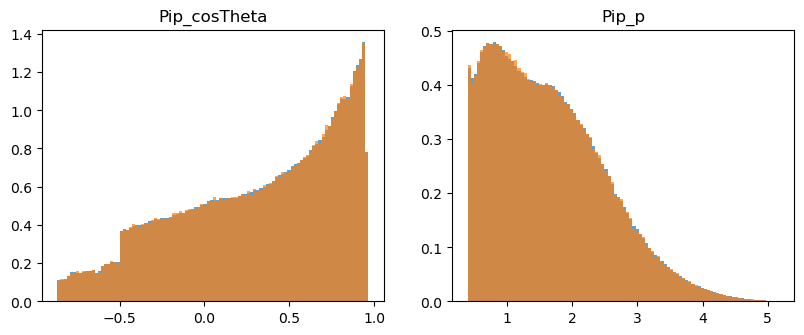

In [290]:
# define base reweighter
# reweighter_base = reweight.GBReweighter(n_estimators=50, 
                                        # learning_rate=0.1, max_depth=3, min_samples_leaf=1000, 
                                        # gb_args={'subsample': 0.4})
reweighter_base = reweight.GBReweighter(n_estimators=100, 
                                        learning_rate=0.1, max_depth=3, min_samples_leaf=500, 
                                        gb_args={'subsample': 0.4})
reweighter = reweight.FoldingReweighter(reweighter_base, n_folds=2)
# it is not needed divide data into train/test parts; rewighter can be train on the whole samples
reweighter.fit(original, target)

# predict method provides unbiased weights prediction for the whole sample
# folding reweighter contains two reweighters, each is trained on one half of samples
# during predictions each reweighter predicts another half of samples not used in training
folding_weights = reweighter.predict_weights(original)

draw_distributions(original, target, folding_weights)

### GB discrimination for reweighting rule

In [291]:
data = numpy.concatenate([original, target])
labels = numpy.array([0] * len(original) + [1] * len(target))

weights = {}
weights['original'] = original_weights
weights['2-folding'] = folding_weights


for name, new_weights in weights.items():
    W = numpy.concatenate([new_weights / new_weights.sum() * len(target), [1] * len(target)])
    Xtr, Xts, Ytr, Yts, Wtr, Wts = train_test_split(data, labels, W, random_state=42, train_size=0.51)
    clf = GradientBoostingClassifier(subsample=0.3, n_estimators=30).fit(Xtr, Ytr, sample_weight=Wtr)
    
    print(name, roc_auc_score(Yts, clf.predict_proba(Xts)[:, 1], sample_weight=Wts))

original 0.5734861831528124
2-folding 0.5014035426839574
